In [1]:
import pandas as pd
import numpy as np

In [2]:
# Store only the URL string in data1
data1 = 'https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv'

# Download it properly
!wget -O car_fuel_efficiency_2026.csv $data1

# Read the clean file name
df = pd.read_csv('car_fuel_efficiency_2026.csv')
df.head()

--2026-10-07 01:58:12--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/car_fuel_efficiency_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 635180 (620K) [text/plain]
Saving to: ‘car_fuel_efficiency_2026.csv’

car_fuel_efficiency 100%[===================>] 620.29K  --.-KB/s    in 0.01s   

2026-10-07 01:58:12 (57.7 MB/s) - ‘car_fuel_efficiency_2026.csv’ saved [635180/635180]



,model_year,origin,fuel_type,drivetrain,num_doors,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,fuel_efficiency_mpg
0,2006,Europe,Gasoline,Front-wheel drive,4,2180,6,243.0,3870,NaN,31.9
1,2008,Europe,Diesel,Front-wheel drive,4,2390,6,272.0,4210,NaN,31.3
2,1996,Asia,Gasoline,Front-wheel drive,5,2320,6,267.0,4240,17.3,27.5
3,1989,Europe,Gasoline,Front-wheel drive,4,2130,6,258.0,4490,18.7,28.5
4,1994,USA,Diesel,Front-wheel drive,3,2580,7,304.0,4510,17.5,31.0


<Axes: >

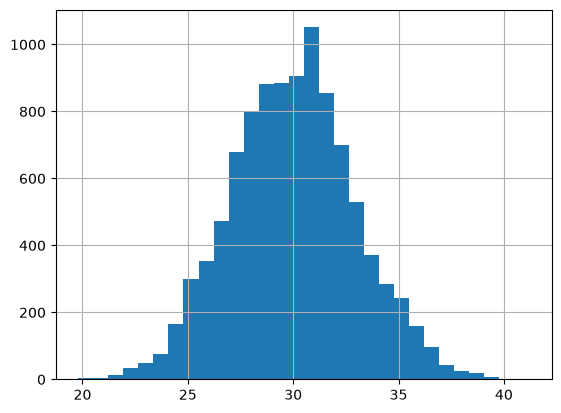

In [8]:
df = df

# EDA: Check distribution of fuel_efficiency_mpg for a long tail
df['fuel_efficiency_mpg'].hist(bins=30)

#### Missing Value

In [9]:
df.isnull().sum()

model_year               0
origin                   0
fuel_type                0
drivetrain               0
num_doors                0
engine_displacement      0
num_cylinders            0
horsepower             877
vehicle_weight           0
acceleration           264
fuel_efficiency_mpg      0
dtype: int64

## Median for Horsepower

In [10]:
df['horsepower'].median()

np.float64(254.0)

## Prepare and Split the Dataset

In [11]:
n = len(df)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = df.iloc[idx[:n_train]].copy()
df_val = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

## Filling NAs

In [12]:
def train_linear_regression(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    XTX = X.T.dot(X)
    if r > 0:
        reg = r * np.eye(XTX.shape[0])
        reg[0] = 0  # Do not regularize the bias term
        XTX = XTX + reg
        
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    return w[0], w[1:]

def rmse(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

features = ['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year']
target = 'fuel_efficiency_mpg'

y_train = df_train[target].values
y_val = df_val[target].values

# Option 1: Fill with 0
X_train_0 = df_train[features].fillna(0).values
w_0, w_weights_0 = train_linear_regression(X_train_0, y_train)
y_pred_0 = w_0 + df_val[features].fillna(0).values.dot(w_weights_0)
score_0 = round(rmse(y_val, y_pred_0), 3)

# Option 2: Fill with mean (computed on training set only)
mean_hp = df_train['horsepower'].mean()
X_train_mean = df_train[features].fillna({'horsepower': mean_hp}).values
w_mean, w_weights_mean = train_linear_regression(X_train_mean, y_train)
y_pred_mean = w_mean + df_val[features].fillna({'horsepower': mean_hp}).values.dot(w_weights_mean)
score_mean = round(rmse(y_val, y_pred_mean), 3)

print(f"RMSE with 0: {score_0}")
print(f"RMSE with mean: {score_mean}")

RMSE with 0: 2.205
RMSE with mean: 2.202


## Best Regularization

In [13]:
X_train_0 = df_train[features].fillna(0).values
X_val_0 = df_val[features].fillna(0).values

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression(X_train_0, y_train, r=r)
    y_pred = w_0 + X_val_0.dot(w)
    score = round(rmse(y_val, y_pred), 4)
    print(f"r={r}: RMSE = {score}")

r=0: RMSE = 2.2053
r=0.01: RMSE = 2.2053
r=0.1: RMSE = 2.2053
r=1: RMSE = 2.2053
r=5: RMSE = 2.2053
r=10: RMSE = 2.2053
r=100: RMSE = 2.2053


## RMSE Standard Deviation

In [14]:
scores = []
seeds = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

for seed in seeds:
    np.random.seed(seed)
    np.random.shuffle(idx)
    
    df_tr = df.iloc[idx[:n_train]].copy()
    df_v = df.iloc[idx[n_train:n_train + n_val]].copy()
    
    y_tr = df_tr[target].values
    y_v = df_v[target].values
    
    X_tr = df_tr[features].fillna(0).values
    X_v = df_v[features].fillna(0).values
    
    w_0, w = train_linear_regression(X_tr, y_tr, r=0.0)
    y_pred = w_0 + X_v.dot(w)
    scores.append(rmse(y_v, y_pred))

std_score = round(np.std(scores), 3)
print(f"Standard deviation of RMSE scores: {std_score}")

Standard deviation of RMSE scores: 0.035


## Evaluation on Test

In [15]:
np.random.seed(9)
np.random.shuffle(idx)

df_train_subset = df.iloc[idx[:n_train]].copy()
df_val_subset = df.iloc[idx[n_train:n_train + n_val]].copy()
df_test = df.iloc[idx[n_train + n_val:]].copy()

# Combine train and validation datasets
df_train_val = pd.concat([df_train_subset, df_val_subset])

y_train_val = df_train_val[target].values
y_test = df_test[target].values

X_train_val = df_train_val[features].fillna(0).values
X_test = df_test[features].fillna(0).values

w_0, w = train_linear_regression(X_train_val, y_train_val, r=0.001)
test_pred = w_0 + X_test.dot(w)
test_rmse = round(rmse(y_test, test_pred), 3)

print(f"Test RMSE: {test_rmse}")

Test RMSE: 2.212
